# Lecture 15 - (21/04/2026)

Today's Topics:

- Natural Language Processing
- Text Classification
- Sentiment Analysis

## NLP

In data science, we are often asked to analyze unstructured text or make a predictive model using it. Unfortunately, most data science techniques require numeric data. NLP libraries provide a tool set of methods to convert unstructured text into meaningful numeric data.

- **Analysis**: NLP techniques provide tools to allow us to understand and analyze large amounts of text. For example:
    - Analyze the positivity/negativity of comments on different websites. 
    - Extract key words from meeting notes and visualize how meeting topics change over time.
- **Vectorizing for machine learning**: When building a machine learning model, we typically must transform our data into numeric features. This process of transforming non-numeric data such as natural language into numeric features is called vectorization. For example:
    - Understanding related words. Using stemming, NLP lets us know that "swim", "swims", and "swimming" all refer to the same base word. This allows us to reduce the number of features used in our model.
    - Identifying important and unique words. Using TF-IDF (term frequency-inverse document frequency), we can identify which words are most likely to be meaningful in a document.

The TextBlob Python library provides a simplified interface for exploring common NLP tasks including part-of-speech tagging, noun phrase extraction, sentiment analysis, classification, translation, and more.

In [1]:
!pip install textblob

### What Is Natural Language Processing (NLP)?

- Using computers to process (analyze, understand, generate) natural human languages.
- Making sense of human knowledge stored as unstructured text.
- Building probabilistic models using data about a language.

Some of the high level tasks we hope to acomplish with NLP include:

- Chatbots: Understand natural language from the user and return intelligent responses.
- Information retrieval: Find relevant results and similar results.
- Information extraction: Structured information from unstructured documents.
- Machine translation: One language to another.
- Text simplification: Preserve the meaning of text, but simplify the grammar and vocabulary.
- Predictive text input: Faster or easier typing.
- Sentiment analysis: Attitude of speaker.
- Automatic summarization: Extractive or abstractive summarization.
- Natural language generation: Generate text from data.
- Speech recognition and generation: Speech-to-text, text-to-speech.
- Question answering: Determine the intent of the question, match query with knowledge base, evaluate hypotheses.

Unfortunately, the NLP programming libraries typically do not provide direct solutions for the high-level tasks above. Instead, they provide low-level building blocks that enable us to craft our own solutions. These include:

- Tokenization: Breaking text into tokens (words, sentences, n-grams)
- Stop-word removal: a/an/the
- Stemming and lemmatization: root word
- TF-IDF: word importance
- Part-of-speech tagging: noun/verb/adjective
- Named entity recognition: person/organization/location
- Spelling correction: "New Yrok City"
- Word sense disambiguation: "buy a mouse"
- Segmentation: "New York City subway"
- Language detection: "translate this page"
- Machine learning: specialized models that work well with text

In [2]:
import pandas as pd
import numpy as np
import scipy as sp
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB         # Naive Bayes
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from textblob import TextBlob, Word
from nltk.stem.snowball import SnowballStemmer

%matplotlib inline

In [3]:
# Read yelp.csv into a DataFrame.
path = 'https://raw.githubusercontent.com/justmarkham/DAT7/refs/heads/master/data/yelp.csv'
yelp = pd.read_csv(path)

# Create a new DataFrame that only contains the 5-star and 1-star reviews.
yelp_best_worst = yelp[(yelp.stars==5) | (yelp.stars==1)]

# Define X and y.
X = yelp_best_worst.text
y = yelp_best_worst.stars

# Split the new DataFrame into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

In [4]:
pd.Series([True, True, False, False]) | pd.Series([True, False, True, False])

# | takes the first item in the first list and compares it with the second list wit an or condition

0     True
1     True
2     True
3    False
dtype: bool

In [5]:
# The head of the original data
yelp.head()


,business_id,date,review_id,stars,text,type,user_id,cool,useful,funny
0,9yKzy9PApeiPPOUJEtnvkg,2011-01-26,fWKvX83p0-ka4JS3dc6E5A,5,My wife took me here on my birthday for breakf...,review,rLtl8ZkDX5vH5nAx9C3q5Q,2,5,0
1,ZRJwVLyzEJq1VAihDhYiow,2011-07-27,IjZ33sJrzXqU-0X6U8NwyA,5,I have no idea why some people give bad review...,review,0a2KyEL0d3Yb1V6aivbIuQ,0,0,0
2,6oRAC4uyJCsJl1X0WZpVSA,2012-06-14,IESLBzqUCLdSzSqm0eCSxQ,4,love the gyro plate. Rice is so good and I als...,review,0hT2KtfLiobPvh6cDC8JQg,0,1,0
3,_1QQZuf4zZOyFCvXc0o6Vg,2010-05-27,G-WvGaISbqqaMHlNnByodA,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",review,uZetl9T0NcROGOyFfughhg,1,2,0
4,6ozycU1RpktNG2-1BroVtw,2012-01-05,1uJFq2r5QfJG_6ExMRCaGw,5,General Manager Scott Petello is a good egg!!!...,review,vYmM4KTsC8ZfQBg-j5MWkw,0,0,0


In [6]:
# The head of the new data
yelp_best_worst.head()

,business_id,date,review_id,stars,text,type,user_id,cool,useful,funny
0,9yKzy9PApeiPPOUJEtnvkg,2011-01-26,fWKvX83p0-ka4JS3dc6E5A,5,My wife took me here on my birthday for breakf...,review,rLtl8ZkDX5vH5nAx9C3q5Q,2,5,0
1,ZRJwVLyzEJq1VAihDhYiow,2011-07-27,IjZ33sJrzXqU-0X6U8NwyA,5,I have no idea why some people give bad review...,review,0a2KyEL0d3Yb1V6aivbIuQ,0,0,0
3,_1QQZuf4zZOyFCvXc0o6Vg,2010-05-27,G-WvGaISbqqaMHlNnByodA,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",review,uZetl9T0NcROGOyFfughhg,1,2,0
4,6ozycU1RpktNG2-1BroVtw,2012-01-05,1uJFq2r5QfJG_6ExMRCaGw,5,General Manager Scott Petello is a good egg!!!...,review,vYmM4KTsC8ZfQBg-j5MWkw,0,0,0
6,zp713qNhx8d9KCJJnrw1xA,2010-02-12,riFQ3vxNpP4rWLk_CSri2A,5,Drop what you're doing and drive here. After I...,review,wFweIWhv2fREZV_dYkz_1g,7,7,4


## Text Classification

Text classification is the task of predicting which category or topic a text sample is from.

We may want to identify:

- Is an article a sports or business story?
- Does an email have positive or negative sentiment?
- Is the rating of a recipe 1, 2, 3, 4, or 5 stars?

Predictions are often made by using the words as features and the label as the target output.

Starting out, we will make each unique word (across all documents) a single feature. In any given corpora, we may have hundreds of thousands of unique words, so we may have hundreds of thousands of features!

- For a given document, the numeric value of each feature could be the number of times the word appears in the document.
- This technique for vectorizing text is referred to as a bag-of-words model. 
  - It is called bag of words because the document's structure is lost — as if the words are all jumbled up in a bag.
  - The first step to creating a bag-of-words model is to create a vocabulary of all possible words in the corpora.

![image](https://miro.medium.com/v2/resize:fit:1322/format:webp/1*sX2Y1Y9Au0hCJzj9qQBV5g.png)

Let's try text processing in scikit-learn

In [7]:
# Use CountVectorizer to create document-term matrices from X_train and X_test.
vect = CountVectorizer()
X_train_dtm = vect.fit_transform(X_train) #fit and transform in one line on the training data
X_test_dtm = vect.transform(X_test) #only transform on test

In [8]:
vect.transform(X_train)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 237720 stored elements and shape (3064, 16825)>

In [9]:
237720 / 3064 / 16825 # % of values in matric that are not zero

0.004611284184063408

In [10]:
vect.transform(X_train).todense()

matrix([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(3064, 16825))

In [11]:
# Rows are documents, columns are terms (aka "tokens" or "features", individual words in this situation).
X_train_dtm.shape

(3064, 16825)

In [12]:
# Last 50 features
print((vect.get_feature_names_out()[-50:]))

['yyyyy' 'z11' 'za' 'zabba' 'zach' 'zam' 'zanella' 'zankou' 'zappos'
 'zatsiki' 'zen' 'zero' 'zest' 'zexperience' 'zha' 'zhou' 'zia'
 'zihuatenejo' 'zilch' 'zin' 'zinburger' 'zinburgergeist' 'zinc'
 'zinfandel' 'zing' 'zip' 'zipcar' 'zipper' 'zippers' 'zipps' 'ziti' 'zoe'
 'zombi' 'zombies' 'zone' 'zones' 'zoning' 'zoo' 'zoyo' 'zucca' 'zucchini'
 'zuchinni' 'zumba' 'zupa' 'zuzu' 'zwiebel' 'zzed' 'éclairs' 'école' 'ém']


In [13]:
pd.DataFrame(X_train_dtm.todense(), columns=vect.get_feature_names_out())

,00,000,00a,00am,00pm,01,02,03,03342,04,...,zucchini,zuchinni,zumba,zupa,zuzu,zwiebel,zzed,éclairs,école,ém
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3059,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3060,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3061,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3062,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [14]:
vect

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"stop_words stop_words: {'english'}, list, default=NoneIf 'english', a built-in stop word list for English is used.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str or None, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp select tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentword n-grams or char n-grams to be extracted. All values of n suchsuch that min_n <= n <= max_n will be used. For example an``ngram_range`` of ``(1, 1)`` means only unigrams, ``(1, 2)`` meansunigrams and bigrams, and ``(2, 2)`` means only bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word n-gram or charactern-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21Since v0.21, if ``input`` is ``filename`` or ``file``, the data isfirst read from the file and then passed to the given callableanalyzer.",'word'


One common method of reducing the number of features is converting all text to lowercase before generating features! Note that to a computer, aPPle is a different token/"word" than apple. So, by converting both to lowercase letters, it ensures fewer features will be generated. It might be useful not to convert them to lowercase if capitalization matters.

In [15]:
# Don't convert to lowercase.
vect = CountVectorizer(lowercase=False)
X_train_dtm = vect.fit_transform(X_train)
print(X_train_dtm.shape)
vect.get_feature_names_out()[-10:]

(3064, 20838)


array(['zoning', 'zoo', 'zucchini', 'zuchinni', 'zupa', 'zwiebel', 'zzed',
       'École', 'éclairs', 'ém'], dtype=object)

In [16]:
X_train.head()

6841    FILLY-B's!!!!!  only 8 reviews?? NINE now!!!\r...
1728    My husband and I absolutely LOVE this restaura...
3853    We went today after lunch. I got my usual of l...
671     Totally dissapointed.  I had purchased a coupo...
4920    Costco Travel - My husband and I recently retu...
Name: text, dtype: str

In [17]:
X_train.loc[0]

'My wife took me here on my birthday for breakfast and it was excellent.  The weather was perfect which made sitting outside overlooking their grounds an absolute pleasure.  Our waitress was excellent and our food arrived quickly on the semi-busy Saturday morning.  It looked like the place fills up pretty quickly so the earlier you get here the better.\r\n\r\nDo yourself a favor and get their Bloody Mary.  It was phenomenal and simply the best I\'ve ever had.  I\'m pretty sure they only use ingredients from their garden and blend them fresh when you order it.  It was amazing.\r\n\r\nWhile EVERYTHING on the menu looks excellent, I had the white truffle scrambled eggs vegetable skillet and it was tasty and delicious.  It came with 2 pieces of their griddled bread with was amazing and it absolutely made the meal complete.  It was the best "toast" I\'ve ever had.\r\n\r\nAnyway, I can\'t wait to go back!'

In [18]:
X_train_dtm.todense()[:5,:] # equivilent to .head forscipy matrix

matrix([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(5, 20838))

In [19]:
list(vect.vocabulary_.items())[:15]

[('FILLY', 2376),
 ('only', 15338),
 ('reviews', 17176),
 ('NINE', 4360),
 ('now', 15195),
 ('wow', 20695),
 ('do', 10716),
 ('miss', 14737),
 ('THIS', 6193),
 ('place', 16020),
 ('24hrs', 138),
 ('drive', 10863),
 ('thru', 19445),
 ('or', 15383),
 ('walk', 20329)]

In [20]:
# Finally, let's convert the sparse matrix to a typical ndarray using .toarray()
#   - Remember, this takes up a lot more memory than the sparse matrix! However, this conversion is sometimes necessary.

X_test_dtm.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1022, 16825))

In [21]:
# We will use this function below for simplicity.

# Define a function that accepts a vectorizer and calculates the accuracy.
def tokenize_test(vect):
    X_train_dtm = vect.fit_transform(X_train)
    print(('Features: ', X_train_dtm.shape[1]))
    X_test_dtm = vect.transform(X_test)
    nb = MultinomialNB()
    nb.fit(X_train_dtm, y_train)
    y_pred_class = nb.predict(X_test_dtm)
    print(('Accuracy: ', metrics.accuracy_score(y_test, y_pred_class)))


In [22]:
# min_df ignores words that occur less than twice ('df' means "document frequency").
vect = CountVectorizer(min_df=2, max_features=10000)
tokenize_test(vect)


('Features: ', 8783)
('Accuracy: ', 0.9246575342465754)


### Stop-Word Removal

Stop words are some of the most common words in a language. They are used so that a sentence makes sense grammatically, such as prepositions and determiners, e.g., "to," "the," "and." However, they are so commonly used that they are generally worthless for predicting the class of a document. Since "a" appears in spam and non-spam emails, for example, it would only contribute noise to our model.

Example:
- Original: "The dog jumped over the fence"
- After stop-word removal: "dog jumped over fence"

In [23]:
# Remove English stop words.
vect = CountVectorizer(stop_words='english')
tokenize_test(vect)
vect.get_params()

('Features: ', 16528)
('Accuracy: ', 0.9158512720156555)


{'analyzer': 'word',
 'binary': False,
 'decode_error': 'strict',
 'dtype': numpy.int64,
 'encoding': 'utf-8',
 'input': 'content',
 'lowercase': True,
 'max_df': 1.0,
 'max_features': None,
 'min_df': 1,
 'ngram_range': (1, 1),
 'preprocessor': None,
 'stop_words': 'english',
 'strip_accents': None,
 'token_pattern': '(?u)\\b\\w\\w+\\b',
 'tokenizer': None,
 'vocabulary': None}

In [24]:
# Set of stop words
print((vect.get_stop_words()))

frozenset({'anywhere', 'be', 'anyhow', 'he', 'these', 'amount', 'somewhere', 'either', 'with', 'bill', 'hereby', 're', 'becoming', 'below', 'had', 'being', 'four', 'him', 'yourselves', 'ever', 'first', 'you', 'they', 'amongst', 'ourselves', 'anything', 'been', 'nobody', 'ten', 'own', 'latterly', 'thin', 'one', 'fill', 'whereupon', 'behind', 'beside', 'everything', 'forty', 'during', 'call', 'cannot', 'towards', 'though', 'hence', 'therein', 'something', 'who', 'nor', 'others', 'least', 'full', 'another', 'take', 'less', 'hundred', 'besides', 'beyond', 'yours', 'sincere', 'between', 'front', 'twenty', 'seems', 'whoever', 'becomes', 'are', 'since', 'nowhere', 'beforehand', 'enough', 'further', 'done', 'me', 'made', 'among', 'no', 'yourself', 'anyone', 'ours', 'etc', 'move', 'whole', 'once', 'in', 'after', 'than', 'eight', 'was', 'some', 'for', 'whenever', 'out', 'everywhere', 'have', 'serious', 'to', 'twelve', 'upon', 'within', 'an', 'herein', 'there', 'perhaps', 'find', 'sometime', 'if'

## TF-IDF Summary

Reddit's autotldr uses the [SMMRY](https://smmry.com/about) algorithm, which is based on TF–IDF.

In [25]:
# Create a document-term matrix using TF–IDF.
vect = TfidfVectorizer(stop_words='english')

# Fit transform Yelp data.
dtm = vect.fit_transform(yelp.text)
features = vect.get_feature_names_out()
dtm.shape


(10000, 28880)

In [26]:
pd.DataFrame(dtm.todense(), columns=features)

,00,000,007,00a,00am,00pm,01,02,03,03342,...,zuzus,zweigel,zwiebel,zy,zzed,zzzzzzzzzzzzzzzzz,éclairs,école,ém,òc
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.140444,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [27]:
import nltk
nltk.download('punkt_tab')

def summarize():
    
    # Choose a random review that is at least 300 characters.
    review_length = 0
    while review_length < 300:
        review_id = np.random.randint(0, len(yelp))
        review_text = yelp.text[review_id]
        review_length = len(review_text)
    
    # Create a mapping from word to column index 
    feature_index = {word: i for i, word in enumerate(features)}
    
    # Create a dictionary of words and their TF–IDF scores.
    word_scores = {}
    
    # (optional: avoid TextBlob dependency issues)
    import re
    words = re.findall(r'\b\w+\b', review_text.lower())
    
    for word in words:
        if word in feature_index:
            idx = feature_index[word]
            word_scores[word] = dtm[review_id, idx]
    
    # Print words with the top five TF–IDF scores.
    print('TOP SCORING WORDS:')
    top_scores = sorted(word_scores.items(), key=lambda x: x[1], reverse=True)[:5]
    for word, score in top_scores:
        print(word)
    
    # Print five random words.
    print('\nRANDOM WORDS:')
    if len(word_scores) >= 5:
        random_words = np.random.choice(list(word_scores.keys()), size=5, replace=False)
        for word in random_words:
            print(word)
    
    # Print the review.
    print('\n' + review_text)

[nltk_data] Downloading package punkt_tab to /Users/ko/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [28]:
review = TextBlob(yelp_best_worst.text[0])
print(review)

My wife took me here on my birthday for breakfast and it was excellent.  The weather was perfect which made sitting outside overlooking their grounds an absolute pleasure.  Our waitress was excellent and our food arrived quickly on the semi-busy Saturday morning.  It looked like the place fills up pretty quickly so the earlier you get here the better.

Do yourself a favor and get their Bloody Mary.  It was phenomenal and simply the best I've ever had.  I'm pretty sure they only use ingredients from their garden and blend them fresh when you order it.  It was amazing.

While EVERYTHING on the menu looks excellent, I had the white truffle scrambled eggs vegetable skillet and it was tasty and delicious.  It came with 2 pieces of their griddled bread with was amazing and it absolutely made the meal complete.  It was the best "toast" I've ever had.

Anyway, I can't wait to go back!


In [29]:
summarize()

TOP SCORING WORDS:
lemon
expected
salad
mozzarella
ciabatta

RANDOM WORDS:
dressing
sticking
price
di
satisfied

So, this will not be my best review, especially when I expected so much more from this place.

Lets get this out of the way and on the table first, this ws not a bad place to go, but, it wasnt my favorite by any means.  I went in expecting to pay a lot for the meal, and rightfully expected the best food I have ever had, and that was just NOT the case.  From the high prices to the limited menu, I would expect this place to specialize in the particular menu items, and would hope to have my taste buds dancing while I shout for more.  I didnt.

We started the meal with burratta forno cotto mozzarella.  it consists of oven baked burrata mozzarella served with grilled ciabatta, fried eggplant, lemon-truffle vinaigrette and parsley.  There were only two tiny ciabatta slices which was not the first complaint.  the second complaint would be that the fried eggplant could have used a b

## Sentiment Analysis

Understanding how positive or negative a review is. There are many ways in practice to compute a sentiment value. For example:

- Have a list of "positive" words and a list of "negative" words and count how many occur in a document. 
- Train a classifier given many examples of "positive" documents and "negative" documents. 

For the most accurate sentiment analysis, you will want to train a custom sentiment model based on documents that are particular to your application. Generic models (such as the one we are about to use!) often do not work as well as hoped.



In [30]:
review = TextBlob(yelp_best_worst.text[0])
print(review)

My wife took me here on my birthday for breakfast and it was excellent.  The weather was perfect which made sitting outside overlooking their grounds an absolute pleasure.  Our waitress was excellent and our food arrived quickly on the semi-busy Saturday morning.  It looked like the place fills up pretty quickly so the earlier you get here the better.

Do yourself a favor and get their Bloody Mary.  It was phenomenal and simply the best I've ever had.  I'm pretty sure they only use ingredients from their garden and blend them fresh when you order it.  It was amazing.

While EVERYTHING on the menu looks excellent, I had the white truffle scrambled eggs vegetable skillet and it was tasty and delicious.  It came with 2 pieces of their griddled bread with was amazing and it absolutely made the meal complete.  It was the best "toast" I've ever had.

Anyway, I can't wait to go back!


In [31]:
# Polarity ranges from -1 (most negative) to 1 (most positive).
review.sentiment.polarity

0.40246913580246907

In [33]:
# Define a function that accepts text and returns the polarity.
def detect_sentiment(text):
    return TextBlob(text).sentiment.polarity
#return TextBlob(text).sentiment.polarity

In [ ]:
# Create a new DataFrame column for sentiment.
yelp['sentiment'] = yelp.text.apply(detect_sentiment)

<Axes: title={'center': 'sentiment'}, xlabel='stars'>

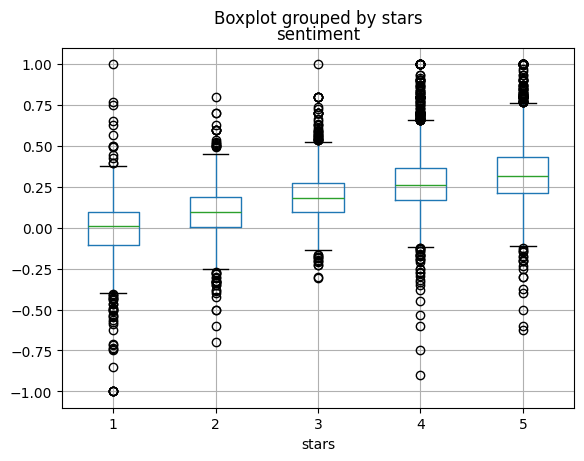

In [35]:
# Box plot of sentiment grouped by stars
yelp.boxplot(column='sentiment', by='stars')

In [36]:
# Reviews with most positive sentiment
yelp[yelp.sentiment == 1].text.head()


254    Our server Gary was awesome. Food was amazing....
347    3 syllables for this place. \r\nA-MAZ-ING!\r\n...
420                                    LOVE the food!!!!
459    Love it!!! Wish we still lived in Arizona as C...
679                                     Excellent burger
Name: text, dtype: str

In [37]:
# Reviews with most negative sentiment
yelp[yelp.sentiment == -1].text.head()


773     This was absolutely horrible. I got the suprem...
1517                  Nasty workers and over priced trash
3266    Absolutely awful... these guys have NO idea wh...
4766                                       Very bad food!
5812        I wouldn't send my worst enemy to this place.
Name: text, dtype: str

In [38]:
# Widen the column display.
pd.set_option('max_colwidth', 500)

In [39]:
# Negative sentiment in a 5-star review
yelp[(yelp.stars == 5) & (yelp.sentiment < -0.3)].head(1)


,business_id,date,review_id,stars,text,type,user_id,cool,useful,funny,length,sentiment
390,106JT5p8e8Chtd0CZpcARw,2009-08-06,KowGVoP_gygzdSu6Mt3zKQ,5,"RIP AZ Coffee Connection. :( I stopped by two days ago unaware that they had closed. I am severely bummed. This place is irreplaceable! Damn you, Starbucks and McDonalds!",review,jKeaOrPyJ-dI9SNeVqrbww,1,0,0,175,-0.302083


In [40]:
# Positive sentiment in a 1-star review
yelp[(yelp.stars == 1) & (yelp.sentiment > 0.5)].head(1)


,business_id,date,review_id,stars,text,type,user_id,cool,useful,funny,length,sentiment
1781,53YGfwmbW73JhFiemNeyzQ,2012-06-22,Gi-4O3EhE175vujbFGDIew,1,If you like the stuck up Scottsdale vibe this is a good place for you. The food isn't impressive. Nice outdoor seating.,review,Hqgx3IdJAAaoQjvrUnbNvw,0,1,2,119,0.766667
